<center><img src="https://i.imgur.com/YNtjmbq.png" width="800"></center> 


# Comunidades y Modelos


## Dos redes científicas, dos arquitecturas distintas

En esta sesión trabajaremos con dos redes de coautoría científica obtenidas desde Dimensions.

| Red       | Nodos | Enlaces |
| --------- | ----- | ------- |
| neuralNet | 1495  | 1451    |
| covidNet  | 13399 | 87524   |

Cada nodo representa un autor, y cada enlace representa una relación de coautoría entre dos autores.

Las redes de coautoría científica permiten estudiar cómo se organiza la producción de conocimiento dentro de una comunidad académica. Debido a que los enlaces representan colaboración efectiva entre investigadores, la estructura observada puede revelar patrones de:

* cohesión,
* fragmentación,
* circulación de información,
* y formación de grupos especializados.

Sin embargo, las propiedades observadas dependen fuertemente de cómo fue construida la red. En este ejercicio, las redes fueron elaboradas utilizando:

* publicaciones recientes,
* únicamente artículos científicos (excluyendo libros, capítulos o monografías),
* documentos indexados desde el área de ingeniería,
* y publicaciones disponibles en acceso abierto.

Además, las redes comparan temas muy distintos:

* un campo asociado a salud global (`covidNet`),
* y otro vinculado a computación e inteligencia artificial (`neuralNet`).

Por ello, las diferencias estructurales observadas no deben interpretarse únicamente como propiedades “naturales” de los campos científicos, sino también como consecuencia de:

* las decisiones metodológicas de recolección,
* los filtros utilizados,
* y el universo documental efectivamente observado.

Aun con estas limitaciones, las redes de coautoría permiten explorar cómo diferentes formas de colaboración producen arquitecturas científicas distintas.



In [2]:
import networkx as nx
import requests
from io import BytesIO

urlNeural = "https://raw.githubusercontent.com/maestriaInnovacion-magallanes-redes/comunidades/main/data/neuralNet.gml"

urlCovid = "https://raw.githubusercontent.com/maestriaInnovacion-magallanes-redes/comunidades/main/data/covidNet.gml"

# neural network
responseNeural = requests.get(urlNeural)
neuralNet = nx.read_gml(BytesIO(responseNeural.content))

# covid collaboration network
responseCovid = requests.get(urlCovid)
covidNet = nx.read_gml(BytesIO(responseCovid.content))

print(neuralNet)
print(covidNet)

Graph with 1495 nodes and 1451 edges
Graph with 13399 nodes and 87524 edges


# I. Conectividad

Un componente representa un conjunto de nodos conectados entre sí mediante algún camino.

> Los componentes <strong>NO SON COMUNIDADES</strong>, sino fragmentos completamente desconectados de la red.


In [3]:
nx.number_connected_components(neuralNet), nx.number_connected_components(covidNet)

(838, 1755)

El resultado muestra que ambas redes presentan un número elevado de componentes desconectados: 838 en neuralNet y 1755 en covidNet. Esto indica que, en ambos casos, una parte importante de los autores no está conectada indirectamente con el resto de la red.
A primera vista ambas redes parecen muy fragmentadas. Sin embargo, el número de componentes por sí solo no revela cuán grandes son esos fragmentos. Para entender mejor la estructura de conectividad, es necesario analizar el tamaño del componente más grande.

<div class="alert alert-warning" role="alert">
    
#### En Gephi  
    
Valida este resultado  (**Connected Components** en **Statistics**)

</div>

A primera vista ambas redes parecen muy fragmentadas. Sin embargo, el tamaño del componente más grande cambia completamente la interpretación.


In [4]:
max([len(c) for c in nx.connected_components(neuralNet)]),\
max([len(c) for c in nx.connected_components(covidNet)])

(18, 1402)

| Red       | Tamaño mayor componente  |
| --------- | ------------------------- |
| neuralNet | 18                        |
| covidNet  | 1402                      |

* `neuralNet` presenta 838 componentes, pero su componente más grande contiene apenas 18 nodos, el 1.2% de la red total. Esto confirma una red altamente fragmentada, donde la gran mayoría de autores forma grupos pequeños y aislados sin conexión indirecta entre sí.
La estructura observada limita fuertemente la alcanzabilidad global dentro de la red.
* `covidNet` presenta 1755 componentes, pero su componente más grande contiene 1402 nodos, el 10.5% de la red total. Esto indica que una fracción significativa de autores sí pertenece a una misma estructura conectada, con potencial de circulación indirecta de información.
La existencia de este componente mayor amplía considerablemente la capacidad de difusión dentro de la red, aunque el 89.5% restante permanece fragmentado.


## Componente Mayor

<div class="alert alert-info">

Muchas métricas estructurales, como distancia promedio, diámetro o cercanía, 
requieren que exista conectividad entre nodos. 

Por ello, es común realizar estos análisis sobre el componente de mayor tamaño.

</div>

Hallemos quienes son los nodos (autores) presentes en el componente mayor:

In [5]:
maxNeural = max(nx.connected_components(neuralNet),key=len)
maxCovid = max(nx.connected_components(covidNet),key=len)

`maxNeural` y `maxCovid` son los nodos del los componentes mayores. Con ellos, podemos crear el subgrafo:

In [6]:
neuralMayor = neuralNet.subgraph(maxNeural)
covidMayor = covidNet.subgraph(maxCovid)

Exploremos estas redes:

In [7]:
import pandas as pd
# pd.options.display.float_format = "{:.4f}".format

# Función para métricas globales del componente Mayor
def metricas_gc(G, nombre):
    return {"Red": nombre,"Nodos": G.number_of_nodes(),
            "Enlaces": G.number_of_edges(),"Diámetro": nx.diameter(G),  
            "Distancia Media": nx.average_shortest_path_length(G),"Densidad": nx.density(G)}

# Tabla
tabla_gc = pd.DataFrame([metricas_gc(neuralMayor, "neuralMayor"),
                         metricas_gc(covidMayor, "covidMayor")])

tabla_gc

,Red,Nodos,Enlaces,Diámetro,Distancia Media,Densidad
0,neuralMayor,18,153,1,1.000000,1.000000
1,covidMayor,1402,8235,19,8.249052,0.008385


Las diferencias entre ambos componentes más grandes muestran arquitecturas estructurales profundamente distintas. El componente más grande de `neuralNet` corresponde a un **grafo completo** de 18 nodos: todos los autores están directamente conectados entre sí, lo que produce densidad máxima (1.0), distancia media de 1 y diámetro de 1. Sin embargo, este grupo representa apenas el 1.2% de la red completa, la cual permanece altamente fragmentada.




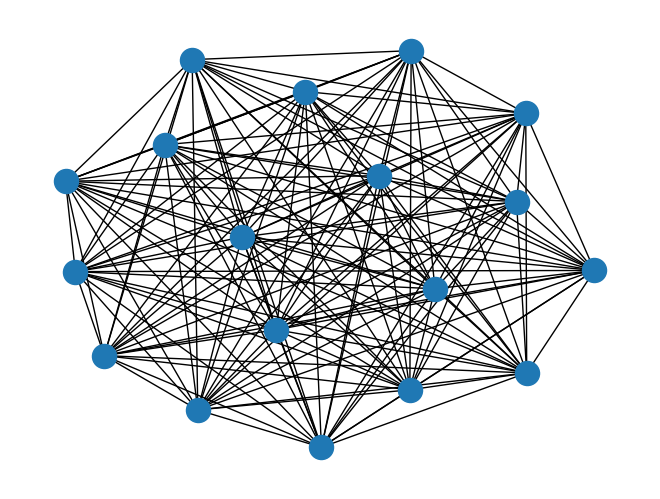

In [8]:
nx.draw(neuralMayor)

En contraste, `covidMayor` conecta indirectamente a 1402 autores con densidad muy baja (0.0084) y distancia media de 8.25. El diámetro de 19 indica que algunos pares de autores están separados por hasta 19 intermediarios, lo que refleja una red extensa donde la conectividad global depende de múltiples intermediarios y donde algunos sectores se encuentran relativamente alejados entre sí desde el punto de vista estructural.

Esto sugiere dos configuraciones estructurales distintas: una basada en grupos pequeños altamente cohesionados pero aislados entre sí, y otra basada en una infraestructura extensa de colaboración con conectividad indirecta a gran escala y trayectorias relativamente largas entre algunos sectores de la red.

<div class="alert alert-warning" role="alert">
    
#### En Gephi  
    
Valida este resultado. Primero quedate con los componentes mayores   (**Filters** -> **Topology** usar filtro **Giant  Component**). De hai ve al menú **Statistics**.

</div>

# II. Comunidades

El componente más grande de `neuralNet` no presenta suficiente complejidad estructural interna para realizar un análisis significativo de comunidades. Debido a que todos los nodos se encuentran directamente conectados entre sí, no existen agrupamientos internos, puentes ni regiones periféricas que permitan identificar subestructuras diferenciadas.

Por ello, el análisis de comunidades resulta mucho más relevante en redes extensas y menos cohesionadas a nivel global, como ocurre en el caso de `covidMayor`.

Hasta ahora hemos analizado propiedades globales de las redes:

* densidad,
* distancia media,
* diámetro,
* y alcanzabilidad.

Sin embargo, muchas redes sociales no se organizan homogéneamente. Frecuentemente aparecen:

* grupos densos,
* zonas periféricas,
* regiones altamente conectadas,
* y puentes entre grupos.

Para entender esa organización interna analizaremos:

1. clustering coefficient,
2. transitivity,
3. cliques,
4. comunidades.


---

## 1. Clustering coefficient

El clustering coefficient mide hasta qué punto los vecinos de un nodo también se encuentran conectados entre sí.

En términos simples:

> ¿Son mis amigos también son amigos entre sí?

Cuando el clustering es alto:

* aparecen triángulos,
* la cohesión local aumenta,
* y la red tiende a formar grupos densos.

En la figura 1, el nodo naranja mantiene cuatro vecinos (2, 3, 4 y 5). Entre esos vecinos podrían existir hasta seis conexiones posibles. A medida que aumentan las conexiones entre ellos (líneas rojas), el clustering coefficient del nodo aumenta progresivamente desde 0 hasta 1.

<figure>
<img src="https://github.com/SocialAnalytics-StrategicIntelligence/SocialNet_analytics/raw/main/picsForSession/LocalClustCoeff.png" style="width:70%">
<figcaption align = "center"> Figura 1. Average clustering coefficient. 
 </figcaption>
 <a href="https://www.researchgate.net/publication/42763973_Toward_a_Network_Perspective_of_the_Study_of_Resilience_in_Social-Ecological_Systems">Fuente: Ecology and Society</a>
</figure>

Cuando el valor es:

* cercano a 0, los vecinos casi no se conectan entre sí;
* cercano a 1, los vecinos forman un grupo altamente cohesionado.

Por ello, el clustering coefficient es una medida de cohesión local y cierre estructural.


In [9]:
nx.average_clustering(covidMayor)

0.9235709398210988

El clustering coefficient promedio muestra una aparente paradoja entre cohesión global y cohesión local. Aunque `covidMayor` presenta una densidad muy baja (~0.0084), su clustering coefficient promedio es extremadamente alto (~0.92).

Sin embargo, este valor debe interpretarse con cautela. En redes de coautoría, los artículos con múltiples autores generan naturalmente pequeños grupos completamente conectados, donde todos los miembros quedan vinculados entre sí. Esto incrementa el clustering promedio de forma casi mecánica, especialmente en nodos de bajo grado, donde el coeficiente puede alcanzar valores trivialmente altos.

Por ello, el valor observado no debe interpretarse exclusivamente como evidencia de cohesión social sustantiva, sino también como consecuencia parcial de la propia mecánica de construcción de redes de coautoría científica.

Dicho esto, la red sí presenta una tendencia real hacia la agrupación local. `covidMayor` combina:

* baja densidad global,
* amplias distancias indirectas,
* y abundantes estructuras locales densamente conectadas.

Esto sugiere una arquitectura simultáneamente extensa y dispersa a nivel global, pero organizada alrededor de múltiples núcleos locales de colaboración.


## 2. Transitivity

La transitivity mide la proporción global de triángulos observados en la red. Mientras el clustering coefficient promedio promedia el cierre local de cada nodo individualmente, la transitivity resume la tendencia global de la red a formar triángulos.

En la figura 2, la red comienza con varias tríadas abiertas: nodos que comparten un vecino común, pero que aún no se encuentran conectados entre sí. A medida que se agregan enlaces laterales, las tríadas comienzan a cerrarse y aparecen más triángulos completos, aumentando progresivamente la transitivity de la red.

Por ello, valores altos de transitivity indican una fuerte tendencia global al cierre relacional y a la formación de agrupamientos cohesionados.

<figure>
<img src="https://github.com/maestriaInnovacion-magallanes-redes/comunidades/raw/main/pics/transitivity_graph.png" style="width:70%">
<figcaption align = "center"> Figura 2. Transitividad </figcaption>
    <a href="https://transportgeography.org/contents/methods/graph-theory-measures-indices/transitivity-graph/" class="alert-link">Fuente:Transitivity in a Graph</a>
</figure>

In [10]:
nx.transitivity(covidMayor)

0.7343307027714403

Un valor de transitivity de (0.734) indica que aproximadamente el 73% de las tríadas conectadas en la red terminan formando triángulos completos. En términos estructurales, esto significa que existe un nivel elevado de cierre relacional: cuando dos nodos comparten un vecino común, es altamente probable que también se encuentren conectados entre sí. Por ello, la red presenta una fuerte tendencia a formar agrupamientos locales cohesionados, aunque dicho cierre no es perfecto ni homogéneo en toda la estructura.

## 3. Cliques

Un **clique** es un subgrafo donde todos los nodos están conectados directamente entre sí. A diferencia de una comunidad, un clique no requiere ser identificado mediante un algoritmo: es una propiedad estructural exacta y verificable de la red.


### 3.1 Cliques Máximal

Una clique maximal es una clique que no puede ampliarse agregando nuevos nodos sin perder la propiedad de conexión completa entre todos sus miembros. En otras palabras, representa un grupo completamente conectado que ya no puede crecer dentro de la red.



<figure>
<img src="https://github.com/maestriaInnovacion-magallanes-redes/comunidades/raw/main/pics/maximalCl.png" style="width:70%">
<figcaption align = "center"> Figure 3. Cliques maximales. 
 </figcaption>
 <a href="https://math.stackexchange.com/questions/758263/whats-maximal-clique/758267#758267">Fuente: Perry Elliott-Iverson</a>
</figure>

* Cuantos maximales tenemos?

In [11]:
len(list(nx.find_cliques_recursive(covidMayor)))

221


<div class="alert alert-success" role="alert">

La presencia de cliques puede sugerir la existencia de estructura comunitaria, ya que las cliques representan regiones de fuerte cohesión local dentro de la red.
</div>

## 4. Detección

Hasta ahora observamos que la red presenta:

* cohesión local,
* abundantes triángulos,
* y una fuerte tendencia al cierre relacional.

La siguiente pregunta es si esas estructuras producen agrupamientos más amplios dentro de la red.

Para responderla utilizaremos técnicas de detección de comunidades.


> Una **comunidad** es un conjunto de nodos más densamente conectados entre sí que con el resto de la red. Una comunidad no es un componente: un componente corresponde a una subred completamente desconectada de otras dentro de la población de la red estudiada.



### 4.1 Método Louvain

Louvain es uno de los algoritmos más utilizados para detección de comunidades.

Su lógica consiste en:

1. asignar inicialmente cada nodo a su propia comunidad;
2. reasignar nodos iterativamente hacia comunidades vecinas si ello aumenta la modularidad;
3. agrupar las comunidades encontradas en supernodos;
4. repetir el proceso hasta que la modularidad deje de mejorar.

Louvain es:

* rápido,
* eficiente,
* y el algoritmo utilizado por defecto en Gephi para detección de comunidades.


In [12]:
comunidadesCovid = nx.community.louvain_communities(
    covidMayor,
    seed=123
)

**Número de comunidades**

In [13]:
len(comunidadesCovid)

28

**Tamaño de comunidades**

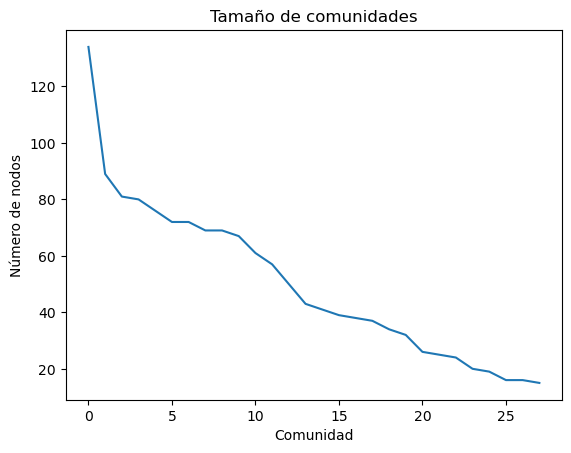

In [14]:
import matplotlib.pyplot as plt 
###

tam_comunidades = sorted(
    [len(c) for c in comunidadesCovid],
    reverse=True
)
plt.plot(tam_comunidades)
plt.xlabel("Comunidad")
plt.ylabel("Número de nodos")
plt.title("Tamaño de comunidades")
plt.show()

### 4.2 Partición

Aqui procedemos a asignar cada nodo a una comunidad:

In [15]:
louvain_attr={z:x for x,y  in enumerate(comunidadesCovid) for z in y }
nx.set_node_attributes(covidMayor, louvain_attr,'louvain')

list(covidMayor.nodes(data=True))[:20]

[('Zhang, Ling', {'louvain': 15}),
 ('Shah, Syed Aziz', {'louvain': 12}),
 ('To, Kelvin Kai-Wang', {'louvain': 26}),
 ('Liu, Peng-Fei', {'louvain': 23}),
 ('Xu, Sihong', {'louvain': 23}),
 ('Hou, Tieying', {'louvain': 20}),
 ('Luo, Changyou', {'louvain': 4}),
 ('Xia, Shubiao', {'louvain': 6}),
 ('Gai, Jing-Gang', {'louvain': 2}),
 ('Cheng, Zhao', {'louvain': 0}),
 ('Chen, Zhulei', {'louvain': 14}),
 ('Tan, Hongwei', {'louvain': 26}),
 ('Li, Genxi', {'louvain': 1}),
 ('Huang, Mingdong', {'louvain': 20}),
 ('Hussain, Tanveer', {'louvain': 8}),
 ('Fan, Jie', {'louvain': 17}),
 ('Li, Jinsong', {'louvain': 19}),
 ('Ni, Yongsheng', {'louvain': 21}),
 ('Zhou, Yaofeng', {'louvain': 19}),
 ('Wang, Fangwei', {'louvain': 23})]

## 5. Modularidad


La modularidad `Q` evalúa qué tan fuerte es la división interna de una red en comunidades.

Valores altos indican:

* grupos relativamente bien definidos,
* mayor densidad interna de conexiones,
* y menor cantidad relativa de enlaces entre comunidades.

Las técnicas modernas de detección de comunidades buscan maximizar la modularidad observada respecto de una red aleatoria equivalente.

| Modularidad `Q` | Interpretación               |
| --------------- | ---------------------------- |
| < 0.3           | estructura comunitaria débil |
| 0.3 – 0.5       | moderada                     |
| 0.5 – 0.7       | fuerte                       |
| > 0.7           | muy fuerte                   |


Veamos:

In [16]:
from networkx.algorithms.community.quality import modularity

modularity(
    covidMayor,
    comunidadesCovid
)

0.9078023406112642

El valor observado de modularidad (Q $\approx$ 0.91) indica que la red presenta una partición estructural altamente diferenciada, donde las comunidades detectadas contienen muchas más conexiones internas de las esperadas bajo una red aleatoria equivalente.

Sin embargo, este resultado debe interpretarse con cautela. En redes muy dispersas y con abundante cierre local —como ocurre frecuentemente en redes de coautoría científica— valores elevados de modularidad pueden emerger parcialmente como consecuencia de la propia fragmentación interna y de la presencia de múltiples grupos densamente conectados.

Asimismo, distintas configuraciones algorítmicas o escalas de análisis pueden producir particiones diferentes sobre una misma red, por lo que las comunidades detectadas deben entenderse como aproximaciones analíticas y no como agrupamientos definitivos u objetivamente “naturales”.

Por ello, una modularidad alta no implica necesariamente la existencia de comunidades socialmente “reales” o perfectamente delimitadas. Más bien, indica que la red presenta agrupamientos internos claramente diferenciados desde el punto de vista estructural bajo el criterio utilizado por el algoritmo de detección.



In [17]:
pos = nx.spring_layout(
    covidMayor,
    seed=123
)

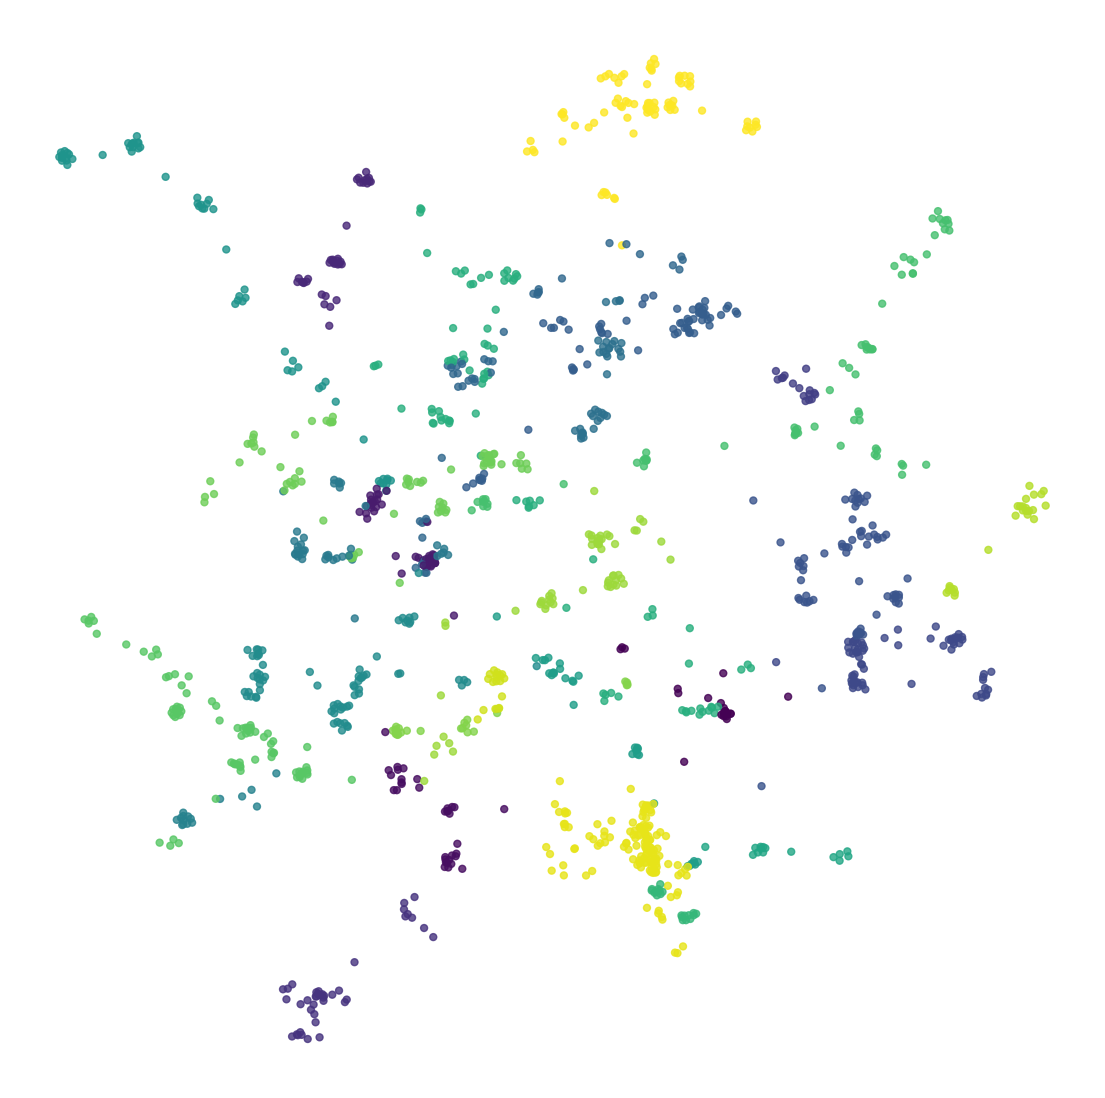

In [18]:
plt.figure(figsize=(14,14))

nx.draw_networkx_nodes(
    covidMayor,
    pos,

    node_color=[
        covidMayor.nodes[n]["louvain"]
        for n in covidMayor.nodes()
    ],

    node_size=25,
    alpha=0.8
)

plt.axis("off")

plt.show()


<div class="alert alert-success" role="alert">

#### Nota Técnica: Algorítmica de Detección de Comunidades

Existen múltiples algoritmos para detección de comunidades. Aunque difieren en sus estrategias computacionales, la mayoría busca identificar grupos de nodos más densamente conectados internamente que con el resto de la red.

Algunos métodos:

* maximizan modularidad (Louvain, Leiden),
* utilizan flujo de información,
* emplean propagación de etiquetas,
* aplican particiones espectrales,
* o estiman probabilidades de conexión entre nodos.

No existe un único algoritmo “correcto”. Diferentes métodos pueden producir particiones distintas dependiendo:

* de la estructura de la red,
* del tamaño,
* de la densidad,
* y del tipo de agrupamientos presentes.

Por ello, la detección de comunidades debe entenderse como una aproximación analítica para explorar la organización interna de una red, y no como una identificación definitiva de grupos “reales”.

</div>

<div class="alert alert-warning" role="alert">
    
#### En Gephi  
    
Calcula **modularity** de covidMayor.

</div>

## Tabla Resumen de Métricas Observadas

Esto es lo que hemos calculado hasta ahora:

| Métrica                       | `neuralMayor`      | `covidMayor` |
| ----------------------------- | ---------------- | ---------- |
| Nodos                         | 18             | 1402      |
| Enlaces                       | 153             | 8235      |
| Densidad (GC)                 | 1.0000           | 0.0084     |
| Diámetro (GC)                 | 1                | 19         |
| Distancia media (GC)          | 1.0000           | 8.2491     |
| Clustering coefficient        | -           | 0.9236     |
| Transitivity                  | -           | 0.7343     |
| Número de cliques maximales   | -     | 221        |
| Número de comunidades Louvain | - | 28         |
| Modularidad (Q)               | - | 0.9080     |


Con ello, pasemos a ver si podemos sintetizar mejor lo encontrado.


# III. Modelos de Red

Hasta ahora hemos analizado:

* conectividad,
* cohesión local,
* cierre triangular,
* y comunidades.

Sin embargo, una pregunta importante permanece abierta:

> ¿Qué tipo de mecanismos pueden producir estas estructuras?

Los modelos de red buscan responder precisamente esa pregunta.

Un modelo de red no intenta reproducir perfectamente una red real. Más bien, representa una aproximación simplificada de ciertos mecanismos de formación de enlaces.

Por ello, los modelos funcionan como herramientas interpretativas:

* ayudan a entender patrones estructurales,
* comparar arquitecturas,
* y generar hipótesis sobre procesos sociales subyacentes.

---

## 1. Modelo Erdös–Rényi (ER)

El modelo ER genera enlaces aleatoriamente entre nodos con una probabilidad (p).

Sus características típicas son:

* distribución relativamente homogénea de conexiones,
* ausencia de hubs importantes,
* bajo clustering,
* y poca estructura comunitaria.

Las redes ER suelen utilizarse como referencia basal o comparación frente a redes reales.

---

## 2. Modelo Barabási–Albert (BA)

El modelo BA introduce el mecanismo de “preferential attachment”:

> los nuevos nodos tienden a conectarse con nodos ya muy conectados.

Esto produce:

* hubs altamente conectados,
* distribución desigual de grado,
* y estructuras tipo “scale-free”.

Las redes BA suelen asociarse con:

* difusión rápida,
* concentración estructural,
* y fuerte dependencia de actores centrales.

---

## 3. Modelo Watts–Strogatz (WS)

El modelo WS busca combinar:

* cohesión local,
* clustering alto,
* y distancias relativamente cortas.

Para ello:

* parte de una red regular,
* e introduce algunos enlaces aleatorios (“shortcuts”).

El resultado suele ser una red:

* altamente agrupada,
* pero globalmente alcanzable.

Este tipo de arquitectura se conoce como:

> small-world network.

<figure>
<img src="https://github.com/maestriaInnovacion-magallanes-redes/comunidades/raw/main/pics/allModels.png" style="width:70%">
<figcaption align = "center"> Figura 4. Modelos de red. 
 </figcaption>
 <a href="https://arxiv.org/abs/2210.07407">Fuente: Anomaly detection in dynamic networks</a>
</figure>

# IV. Modelos como aproximaciones

## 1. Estructura de una red para la innovación

Antes de comparar modelos, vale la pena detenerse en una pregunta más fundamental:

> ¿Qué tiene que ver la forma de una red con cómo se genera, difunde y absorbe el conocimiento?

La respuesta corta es: **todo**. La estructura de una red de colaboración no es un dato neutro. Refleja decisiones, incentivos y barreras que determinan quién accede a qué conocimiento, con qué velocidad, y desde dónde.

Los siguientes conceptos del campo de innovación tienen una traducción directa en propiedades estructurales de redes:

**Innovación abierta**

Chesbrough (2003) propone que las organizaciones no innovan solas: incorporan conocimiento externo y comparten el propio.<sup>1</sup> En términos de red, esto implica la existencia de **puentes entre comunidades**: nodos o enlaces que conectan grupos que de otro modo estarían aislados. Una red sin esos puentes favorece la innovación cerrada, aunque cada grupo interno sea muy productivo.

**Capacidades de absorción**

Cohen y Levinthal (1990) argumentan que la capacidad de una organización para reconocer, asimilar y aplicar conocimiento externo depende de su base de conocimiento previo.<sup>2</sup> En una red, esto se traduce en la **posición estructural** de un nodo: los actores que ya tienen conexiones diversas pueden absorber conocimiento nuevo con mayor facilidad. Un nodo aislado, aunque talentoso, tiene baja capacidad de absorción estructural.

**Redes de colaboración científica**

La producción de conocimiento científico es inherentemente colaborativa. Las redes de coautoría revelan cómo se organiza esa colaboración: si es jerárquica, distribuida o mixta.<sup>3</sup> Cada configuración tiene implicaciones distintas sobre la velocidad de difusión de hallazgos y la formación de consensos.

**Nichos de innovación**

Geels (2002) describe los nichos como espacios donde actores afines co-desarrollan innovaciones radicales, relativamente protegidos de la presión del régimen dominante.<sup>4</sup> En términos de red, un nicho se reconoce por su **alta cohesión interna** y sus **vínculos selectivos hacia el exterior**: suficiente apertura para aprender, suficiente cierre para no disolverse.

**Conocimiento organizacional**

Granovetter (1973) y Coleman (1988) muestran que los grupos altamente cohesionados generan confianza y facilitan la transferencia de conocimiento tácito.<sup>5</sup> Esto se mide en redes como **clustering alto** y **cierre triádico**. Sin embargo, esos mismos grupos pueden volverse endogámicos: circulan el mismo conocimiento entre los mismos actores, reduciendo la novedad.


Con estos conceptos en mente, cada modelo de red puede leerse como una hipótesis sobre cómo se organiza la colaboración y el conocimiento:

| Concepto | Erdös–Rényi (ER) | Barabási–Albert (BA) | Watts–Strogatz (WS) |
|---|---|---|---|
| **Innovación abierta** | La colaboración ocurre por azar, sin preferencia por actores externos. No hay puentes intencionales entre grupos. Modelo poco realista para innovación abierta. | El conocimiento externo llega principalmente a través de hubs. La apertura depende de quién controla los nodos centrales, no de la red en su conjunto. | Grupos cohesionados con algunos puentes hacia otros grupos. Describe bien redes donde la innovación abierta opera de forma moderada y selectiva. |
| **Capacidades de absorción** | Todos los actores tienen posiciones equivalentes. No hay diferencias estructurales en la capacidad de acceder a conocimiento externo. | Los hubs tienen capacidad de absorción estructuralmente alta; los nodos periféricos, muy baja. Reproduce desigualdad estructural en el acceso al conocimiento. | La absorción depende de la posición del actor: los conectores entre grupos tienen ventaja absorptiva sobre quienes permanecen dentro de un solo grupo. |
| **Redes de colaboración científica** | Colaboración sin patrón: cualquier par de autores tiene la misma probabilidad de publicar juntos. No reproduce la realidad observada en ciencia. | Reproduce el fenómeno de "estrella científica": unos pocos autores concentran la mayoría de las coautorías. Común en campos maduros y jerarquizados. | Reproduce grupos de investigación estables con colaboraciones ocasionales fuera del grupo. Patrón frecuente en ciencia interdisciplinaria y en redes como `covidNet`. |
| **Nichos de innovación** | No hay nichos: todos los actores están igualmente expuestos. Un espacio sin estructura no protege ni acelera el desarrollo de innovaciones radicales. | Los nichos se forman alrededor de hubs. El nodo central define quién entra y quién queda fuera, lo que puede acelerar o bloquear la innovación dentro del nicho. | Describe bien la lógica de nicho: comunidades densas e internamente cohesionadas, con vínculos selectivos hacia el exterior que permiten aprender sin perder identidad. |
| **Conocimiento organizacional** | El conocimiento circula de forma homogénea y sin fricción. No considera confianza, jerarquía ni rutinas organizacionales. | El conocimiento se acumula en actores centrales. Reproduce organizaciones con conocimiento concentrado en expertos o directivos clave. | El conocimiento tácito circula bien dentro de grupos cohesionados. El conocimiento nuevo entra por los puentes. Describe bien la tensión entre explotación y exploración. |


## 2. ¿A qué modelo se parece `covidMayor`?

Las redes reales rara vez corresponden exactamente a un único modelo. La pregunta no es cuál modelo es "correcto", sino cuál captura mejor los mecanismos que parecen operar en esta red de colaboración científica.

Para responderla no basta con inspección visual. Necesitamos construir los tres modelos sintéticos en condiciones comparables y medir las mismas métricas que ya conocemos.

### Paso 1: extraer los parámetros base de `covidMayor`

Para que la comparación sea válida, cada modelo sintético debe tener el mismo número de nodos y una densidad equivalente a la red real.

In [19]:
n = covidMayor.number_of_nodes()   # 1402 nodos, ya sabemos
m = covidMayor.number_of_edges()   # 8235 enlaces , ya sabemos

Con esos valores calibramos cada modelo:

- **ER**: `p_er` es la probabilidad de enlace que reproduce en promedio el mismo número de conexiones que `covidMayor`.
- **WS**: `k_ws` es el número de vecinos iniciales de cada nodo, derivado del grado promedio y redondeado al entero par más cercano (requisito del modelo). El parámetro `p=0.1` controla cuántos de esos enlaces se reconectan aleatoriamente: un valor bajo mantiene la estructura local con pocos atajos globales.
- **BA**: `m_ba` es el número de enlaces que agrega cada nodo nuevo al incorporarse a la red.


In [21]:
import numpy as np

p_er = (2 * m) / (n * (n - 1))

valores_grado = np.array([d for _, d in covidMayor.degree()])
k_ws = int(round(valores_grado.mean() / 2) * 2)
m_ba = max(1, int(round(valores_grado.mean() / 2)))

### Paso 2: generar las redes sintéticas


In [22]:
er = nx.erdos_renyi_graph(n=n, p=p_er, seed=42)
ws = nx.watts_strogatz_graph(n=n, k=k_ws, p=0.1, seed=42)
ba = nx.barabasi_albert_graph(n=n, m=m_ba, seed=42)

ER y BA pueden generar nodos desconectados, por lo que extraemos el componente mayor de cada una antes de calcular métricas, de la misma forma que hicimos con `covidMayor`.

In [23]:
def componente_mayor(G):
    return G.subgraph(
        max(nx.connected_components(G), key=len)
    ).copy()

er_mayor = componente_mayor(er)
ws_mayor = componente_mayor(ws)
ba_mayor = componente_mayor(ba)

### Paso 3: calcular y comparar métricas

Usamos tres métricas porque cada una captura una dimensión distinta de la estructura:

- **Clustering promedio**: cohesión local — ¿mis vecinos también se conectan entre sí?
- **Transitivity**: cierre triangular global — ¿qué proporción de tríadas forman triángulos completos?
- **Coeficiente de variación del grado**: desigualdad en conexiones — ¿hay actores mucho más conectados que el promedio?

Estas tres métricas permiten distinguir entre los modelos porque cada uno produce valores característicos muy distintos en ellas.


In [24]:
def metricas(G):
    vals = np.array([d for _, d in G.degree()])
    return {
        "clustering"  : round(nx.average_clustering(G), 4),
        "transitivity": round(nx.transitivity(G), 4),
        "cv_grado"    : round(vals.std() / vals.mean(), 4),
    }


Aplicamos la función a `covidMayor` y a cada modelo sintético:

In [25]:
real = metricas(covidMayor)
er_m = metricas(er_mayor)
ws_m = metricas(ws_mayor)
ba_m = metricas(ba_mayor)

La tabla compara cada modelo contra la red real usando subcolumnas: la columna `covidMayor` repite el valor observado como referencia, y la columna `modelo` muestra el valor sintético. Esto permite ver de un vistazo qué tan lejos está cada modelo de la realidad en cada dimensión:

In [26]:
datos = {
    ("Modelo", "")                           : ["Erdös–Rényi (ER)", "Watts–Strogatz (WS)", "Barabási–Albert (BA)"],
    ("Clustering promedio", "covidMayor")    : [real["clustering"]]  * 3,
    ("Clustering promedio", "modelo")        : [er_m["clustering"],  ws_m["clustering"],  ba_m["clustering"]],
    ("Transitivity",        "covidMayor")    : [real["transitivity"]] * 3,
    ("Transitivity",        "modelo")        : [er_m["transitivity"], ws_m["transitivity"], ba_m["transitivity"]],
    ("Coef. variación grado", "covidMayor")  : [real["cv_grado"]]    * 3,
    ("Coef. variación grado", "modelo")      : [er_m["cv_grado"],    ws_m["cv_grado"],    ba_m["cv_grado"]],
}
pd.DataFrame(datos)

Modelo Clustering promedio         Transitivity          \
                                 covidMayor  modelo   covidMayor  modelo   
0      Erdös–Rényi (ER)              0.9236  0.0074       0.7343  0.0078   
1   Watts–Strogatz (WS)              0.9236  0.4997       0.7343  0.4922   
2  Barabási–Albert (BA)              0.9236  0.0368       0.7343  0.0276   

  Coef. variación grado          
             covidMayor  modelo  
0                0.6834  0.2868  
1                0.6834  0.0877  
2                0.6834  1.0463

La tabla permite tres lecturas directas, una por modelo:

**Erdös–Rényi:** el clustering del modelo es 0.0074 y la transitivity 0.0078, mientras que en `covidMayor` son 0.9236 y 0.7343 respectivamente. La diferencia es alrededor de 100 veces. La colaboración científica en COVID no ocurre por azar: hay mecanismos sociales claros que organizan quién trabaja con quién.

**Barabási–Albert:** el clustering (0.0368) y la transitivity (0.0276) también son muy bajos, descartándolo por la misma razón que ER. Pero hay un segundo problema más revelador: el coeficiente de variación de grado en BA es 1.0463, mientras que en `covidMayor` es 0.6834. Esto significa que `covidMayor` es **menos jerárquica** de lo que BA predice: algunos autores tienen más conexiones que el promedio, pero sin la concentración extrema característica de una red *scale-free*.

**Watts–Strogatz:** es el modelo estructuralmente más cercano en clustering (0.4997) y transitivity (0.4922), pero la diferencia con `covidMayor` sigue siendo considerable: casi el doble en ambas métricas. Llamarlo "cercano" es relativo: WS es simplemente el menos lejano de los tres. Los grupos de coautoría son sustancialmente más cerrados de lo que cualquiera de los modelos estándar predice.

> Esto no es un defecto del análisis sino una limitación conocida de estos modelos frente a redes de coautoría: cuando varios autores publican juntos un artículo, todos quedan conectados entre sí formando una clique completa. Ese mecanismo infla el clustering de forma sistemática y ninguno de los tres modelos lo incorpora. Por ello, `covidMayor` se aproxima más a una arquitectura Watts–Strogatz, pero con cohesión local estructuralmente más alta de lo que WS puede reproducir con sus parámetros estándar.


## 3. Síntesis

`covidMayor` no es aleatoria, no es *scale-free*, y no es exactamente *small-world*. Es una red de colaboración científica real, y eso significa que ningún modelo la describe perfectamente. Sin embargo, la comparación no es un ejercicio vacío: nos dice algo concreto sobre cómo se organiza la producción de conocimiento en este campo.

La imagen que emerge es la de una red construida sobre **grupos de colaboración cerrados y estables**, conectados entre sí de forma selectiva. Traducido a los conceptos del curso:

**Conocimiento organizacional:** el clustering excepcionalmente alto (0.9236, un 85% superior al valor que WS produce) indica que los investigadores tienden a publicar repetidamente con los mismos coautores. Dentro de cada grupo, el conocimiento tácito circula con facilidad: todos se conocen, comparten métodos, lenguaje y supuestos. Pero ese mismo cierre puede convertirse en una trampa: el grupo circula el mismo conocimiento entre los mismos actores, reduciendo la entrada de ideas nuevas desde fuera.

**Nichos de innovación:** las 28 comunidades detectadas con modularidad Q ≈ 0.91 sugieren que la red está organizada en grupos con agendas propias, relativamente bien delimitados. Es razonable suponer que distintos equipos desarrollaron líneas de investigación específicas —epidemiología computacional, vacunas, modelos de transmisión— con poca mezcla entre ellas, aunque confirmarlo requeriría analizar el contenido temático de las publicaciones de cada comunidad.


**Capacidades de absorción:** la heterogeneidad de grado (CV = 0.6834, muy superior al 0.0877 de WS) indica que la distribución de conexiones no es homogénea: algunos autores tienen considerablemente más coautores que el promedio. Eso sugiere la existencia de actores con posiciones estructuralmente ventajosas para acceder a conocimiento externo. Sin embargo, el CV por sí solo no confirma que esos autores conecten comunidades distintas: un autor puede tener grado alto concentrado dentro de un solo grupo. Identificar quiénes tienen genuina capacidad de absorción estructural requeriría analizar su centralidad de intermediación (*betweenness*) o su participación en múltiples comunidades simultáneamente. En términos de Cohen y Levinthal, la heterogeneidad observada es una condición necesaria pero no suficiente para inferir capacidad de absorción diferenciada.


**Innovación abierta:** la ausencia de hubs dominantes (centralización ≈ 0.057) implica que la red no depende de un único conector para mantenerse integrada. Eso es una fortaleza: la red es resiliente ante la salida de cualquier actor individual. Pero también es una advertencia: si los puentes entre comunidades son muchos pero débiles, la transferencia de conocimiento entre nichos puede ser lenta o superficial. La innovación abierta requiere no solo que existan puentes, sino que sean lo suficientemente fuertes como para transferir conocimiento complejo, no solo señales.

**Redes de colaboración científica:** la combinación de cohesión local alta y conectividad global moderada (distancia media ≈ 8.25) describe una red donde la colaboración es profunda dentro de los grupos pero costosa entre ellos. Eso tiene implicaciones directas para política científica: los incentivos que premian la producción dentro de grupos consolidados refuerzan esta arquitectura, mientras que los que premian colaboraciones interdisciplinarias o internacionales generarían puentes que la red actualmente no tiene en abundancia.

> La estructura de `covidMayor` no es un accidente. Refleja cómo se organizó globalmente la comunidad científica ante una crisis: grupos especializados trabajando en paralelo, con conexiones selectivas entre ellos. Esa arquitectura permitió producir conocimiento rápidamente dentro de cada nicho, pero la alta modularidad (Q ≈ 0.91) y las distancias promedio considerables (8.25 saltos) sugieren que la transferencia de conocimiento entre comunidades pudo haber sido lenta o selectiva. Afirmar que las comunidades "no se hablaban entre sí" va más allá de lo que los datos permiten concluir: para eso sería necesario analizar la densidad de enlaces entre comunidades o la centralidad de intermediación de los nodos puente. Lo que sí podemos decir es que la arquitectura observada no favorece estructuralmente la circulación fluida de conocimiento entre grupos.


<div class="alert alert-warning" role="alert">

#### Visualización en Gephi

No todos los layouts son equivalentes. Para redes de coautoría como las de este ejercicio, la elección del layout afecta directamente qué estructura es visible y cuál queda oculta.

**Secuencia recomendada**

1. **Force Atlas 2** — punto de partida para `covidMayor`. Agrupa nodos conectados y separa comunidades visualmente. Activar `Prevent Overlap` y ajustar `Scaling` según el tamaño de la red. Dejar correr hasta que el layout converja (los nodos dejan de moverse).
2. **Noverlap** — aplicar después de Force Atlas 2 para separar nodos que quedaron solapados. No recalcula el layout, solo ajusta posiciones localmente.
3. **Label Adjust** — aplicar al final, solo si se quieren mostrar etiquetas de autores. Mueve las etiquetas para que no se superpongan entre sí.

**Alternativas según el caso**

| Situación | Layout recomendado |
|---|---|
| Red pequeña y densa (`neuralMayor`, 18 nodos) | **Fruchterman Reingold** — distribuye bien grafos densos pequeños |
| Force Atlas 2 tarda demasiado | **Yifan Hu** — produce resultados similares con mayor velocidad |
| Red muy grande (`covidNet` completa, 13399 nodos) | **OpenOrd** — diseñado para redes de decenas de miles de nodos |
| La red tiene pesos en los enlaces | **Yifan Hu Proportional** — escala distancias según el peso de cada enlace |

**Qué evitar**

- **Force Atlas** (sin el 2) — versión anterior, más lenta e inestable. No usar.
- **Random Layout** — distribuye nodos al azar. Solo útil como punto de partida antes de otro layout.
- **Label Adjust / Noverlap como layout principal** — son ajustes post-layout, no layouts. Aplicarlos solos no produce ninguna estructura analíticamente útil.
- **Rotate / Mirror / Contraction / Expansion** — son transformaciones estéticas sin efecto analítico. No aportan información sobre la red.

</div>

<hr>

<small>
<sup>1</sup> Chesbrough, H. W. (2003). The era of open innovation. <em>MIT Sloan Management Review, 44</em>(3), 35–41. 
Lectura sugerida: la sección "From Closed to Open" y el caso Lucent vs. Cisco. 
Disponible en <a href="https://drive.google.com/file/d/1u_E9-JJofuhSHLhTwXwx7V8ab7HOYJEC/view?usp=sharing">carpeta de la sesión</a>.<br><br>

<sup>2</sup> Cohen, W. M., & Levinthal, D. A. (1990). Absorptive capacity: A new perspective on learning and innovation. <em>Administrative Science Quarterly, 35</em>(1), 128–152. 
Lectura sugerida: la introducción y la sección "Absorptive Capacity". 
Disponible en <a href="https://drive.google.com/file/d/1s81C3PwLEP4WDHknKpXo61VD-XClfEUt/view?usp=sharing">carpeta de la sesión</a><br><br>

<sup>3</sup> Granovetter, M. S. (1973). The strength of weak ties. <em>American Journal of Sociology, 78</em>(6), 1360–1380. 
Lectura sugerida: la introducción y la sección sobre "forbidden triads". Para una entrada más accesible ver: <a href="https://drive.google.com/file/d/119tOPM7DS6Hp9-xnu6YBsRY3w1DLeh25/view?usp=sharing">carpeta de la sesión</a><br><br> [original aqui](https://drive.google.com/file/d/1StSN61JwItEQMSf_Hd3ry321nrC8YEVc/view?usp=sharing)

<sup>4</sup> Geels, F. W. (2002). Technological transitions as evolutionary reconfiguration processes. <em>Research Policy, 31</em>(8–9), 1257–1274. 
Lectura sugerida: la introducción y la descripción de los tres niveles (nicho, régimen, paisaje). 
Disponible en <a href="https://drive.google.com/file/d/1p1fOpGKDN4Os8artwU4aCY5d02tngu8q/view?usp=sharing">carpeta de la sesión</a><br><br>

<sup>5</sup> Granovetter (1973), op. cit. Para cohesión y cierre estructural, ver además: Coleman, J. S. (1988). Social capital in the creation of human capital. <em>American Journal of Sociology, 94</em>(Suplemento), S95–S120. 
Lectura sugerida: la introducción y la sección "Forms of Social Capital". 
Disponible en <a href="https://drive.google.com/file/d/15dYJwS5j3mChcDMsbI4Q0A3lsxUwZY7X/view?usp=sharing">carpeta de la sesión</a>
</small>